# CNN-based multiclass classifier

### Description

Experiment 2: ModelCNNExp1 (BRCBJJ9G5)

The model is configured with regularised layers. 
The model is configured with regularised layers. Input normalisation is the only data preprocessing technique applied (for all train, val, and test data). Light data augmentation was applied for both train and valid data. The optimiser is Adamax, with a loss function of categorical_crossentropy. The metrics are accuracy. The learning rate scheduler is Cosine decay, with an initial LR of 0.001, a decay steps ratio of 0.75, and an alpha of 0.1. The model was fully trained for 200 epochs with a batch size of 16.

In [1]:
# For the sake of convenience, just single file for now.
# ============
## TIMESTAMP @ 2024-11-07T16:34:02

# Exp with transfer learning approach
# Pretrained weight from Imagenet
# Optimizer: AdamW, Adamax
"""
Experiment Code:
Model: ModelCNNExp1 
Pretrained weights: imagenet
Training type: Training all layers.
Output layers: 
Regularizer layer: Dropout
Data augmentation: Yes
Optimizer: Adamax
LearningRate Scheduler: Consine decay
LearningRate Scheduler opt: 0.9, 0.1
epochs: 100
batchsize: 16
"""
# Import necessary libs

import os, io
import datetime
import time
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import logging
import random
import string
# These lib should be placed at the same level at the notebook
import dev_configuration
import dev_dataprocesses
import itertools

2024-12-16 23:59:35.782986: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-16 23:59:35.783002: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-16 23:59:35.783008: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-16 23:59:35.786696: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
## Configuration

In [3]:
randomState_value = 2024

# Dataset configuration
datasets  = ['chest_xray_small', 'chest-xray-full', 'sport-balls']
dataset_name = 'sport-balls'
dataset_original_path = f"./datasets/{dataset_name}/"
test_split_value = 0.2 # split ratio of test from the given data source
val_split_value = 0.3 # split ratio of validation from the given data source
# keras datagenerators configuration
default_xcol_value = 'filepath'
default_ycol_value = 'label'
isShuffle = True

# Debug flags
# legacy flags
isDebug = False
isVerbose = True
is_config_exp = False # Disable model archs definition list
# Image size configuration
# legacy
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
# Model configuration
# Learning configuration
model_loss_opt = 'categorical_crossentropy'
learning_rate = 0.001
# learning cosine decay rate
decay_rate = 0.75
decay_alpha_value = 0.1

# default setting for long run
enableEarlyStopping = False
enableEarlyStopping_threshold = 10
epochs = 200
batch_size = 32 # GPU RAM should be at least 24GB
if isDebug:
    # Debug run
    epochs = 10
    batch_size = 16
else:
    # Normal run
    epochs = 200
    batch_size = 16 # Run on small gpu portion
# for transfer learning/finetuning
pretrained_weights = 'imagenet' # Pretrained weights
frozen_weights = False # True: Freeze all base layers. False: otherwise.
# For regulariser layers
kernel_l_value = 0.001
act_l_value = 0.001
drop_out_value_1 = 0.5
drop_out_value_2 = 0.3
drop_out_value_3 = 0.1
models_archs = ['ModelCNNExp1', 'ModelCNNExp2', 'ModelCNNExp3', 'ModelCNNExp4']

In [4]:
# Logging and artifacts configuration
# Generate unique exp string
digits = random.choices(string.digits, k=2)
letters = random.choices(string.ascii_uppercase, k=9)
uniq_sample = f"".join(random.sample(digits + letters, 9))

# Setting up folders and logging
exp_base_dir = f"./experiments/"
model_sel = 'ModelCNNExp1'
# configurations for output layers after base-layer
config_output_arc = 'config_5'

augmentation_opts = {
            'rescale': 1./255., # Remember to set None if model is EfficientNet
            'rotation_range': 0,
            'width_shift_range': 0.0,
            'height_shift_range': 0.0,
            'zoom_range': 0.0,
            'horizontal_flip': True,
            'vertical_flip': True,
        }
if model_sel == 'EfficientNetB3':
    augmentation_opts['rescale'] = None

#augmentation_options = f"rescale width_shift_range height_shift_range zoom_range horizontal_flip=True vertical_flip=True"
augmentation_options = f"".join([f"{key}_{augmentation_opts[key]}_" for key in augmentation_opts.keys()])

# augmentation_options = f"augs_rescale rot=no horizontal_flip=True vertical_flip=True"
#augmentation_options = f"augs_rescale rot=no horizontal_flip=no vertical_flip=no"
other_options = (f"_no_pool_in_base_{config_output_arc}_activity_reg_{act_l_value}_kernel_reg_{kernel_l_value}_dropout_0.3_0.3"
                 f"\nlearning rate decay: Adamax, "
                 f"\n decay_rate_{decay_rate}_alpha_{decay_alpha_value}")


In [5]:
## Preparation

In [6]:
current_datestamp = datetime.datetime.now().strftime("%Y%m%d")
exp_folder = f"{model_sel}-{current_datestamp}_{uniq_sample}"

logs_text_dir = os.path.join(exp_base_dir, exp_folder, "logs")
checkpoints_dir = os.path.join(exp_base_dir, exp_folder, "checkpoints")

current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_filename = f"{logs_text_dir}/{model_sel}-{current_timestamp}.log"

if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir, exist_ok=True)

if not os.path.exists(logs_text_dir):
    os.makedirs(logs_text_dir, exist_ok=True)

# Create a logger
logger = logging.getLogger('my_logger')
logger.setLevel(logging.DEBUG)

# Create a formatter to define the log format
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')

# Create a file handler to write logs to a file
file_handler = logging.FileHandler(log_filename)
file_handler.setLevel(logging.DEBUG)
file_handler.setFormatter(formatter)

# Create a stream handler to print logs to the console
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)  # You can set the desired log level for console output
console_handler.setFormatter(formatter)

# Add the handlers to the logger
logger.addHandler(file_handler)
logger.addHandler(console_handler)

logger.info(f"Datetime: {current_timestamp}"
            f"\n Setup all folders and files:"
            f"\n Unique expname: {uniq_sample}"
            f"\n exp_folder: {exp_folder}"
            f"\n -logs_text_dir dir: {logs_text_dir}"
            f"\n -checkpoints_dir : {checkpoints_dir}")


2024-12-16 23:59:37,614 - INFO - Datetime: 20241216-235937
 Setup all folders and files:
 Unique expname: BRCBJJ9G5
 exp_folder: ModelCNNExp1-20241216_BRCBJJ9G5
 -logs_text_dir dir: ./experiments/ModelCNNExp1-20241216_BRCBJJ9G5/logs
 -checkpoints_dir : ./experiments/ModelCNNExp1-20241216_BRCBJJ9G5/checkpoints


In [7]:
## Helpers function

In [8]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Oranges,
                          figname='figname.png'):
    plt.figure(figsize=(10, 10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized Confusion Matrix')
    else:
        print('Confusion Matrix, Without Normalization')
    print(cm)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(fig_name)

def get_model_summary(model):
    stream = io.StringIO()
    model.summary(print_fn=lambda x: stream.write(x + '\n'))
    summary_string = stream.getvalue()
    stream.close()
    return summary_string

class LearningRateLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(self.model.optimizer.iterations)
        logs['learning_rate'] = float(tf.keras.backend.get_value(lr))

In [9]:
# Generate data for training

In [10]:
## Data preparation

In [11]:
loaded_datasets = dev_dataprocesses.load_dataset(preconfigured_dataset=dataset_name)

train_data, val_data, test_data = dev_dataprocesses.data_generators(
    datasource=loaded_datasets,
    data_generator='keras',
    test_split_value = test_split_value,
    val_split_value = val_split_value,
    randomState_value = randomState_value,
    default_xcol_value = default_xcol_value,
    default_ycol_value = default_ycol_value,
    batch_size = batch_size,
    isShuffle = isShuffle,
    augmentation_opts = augmentation_opts
)

Processing ./datasets/sport-balls
Processing train set
Processing test set
 processes completed
 3

 Label: train 
Length is : 7328
Sample head: 
                                             filepath     label
0  ./datasets/sport-balls/train/baseball/baseball...  baseball
1  ./datasets/sport-balls/train/baseball/baseball...  baseball
2  ./datasets/sport-balls/train/baseball/baseball...  baseball
3  ./datasets/sport-balls/train/baseball/baseball...  baseball
4  ./datasets/sport-balls/train/baseball/baseball...  baseball
Sample shape: 
 (7328, 2)
Value counts: 
 label
billiard_ball        646
table_tennis_ball    620
football             604
cricket_ball         581
golf_ball            549
hockey_ball          530
rugby_ball           493
tennis_ball          490
bowling_ball         440
volleyball           432
shuttlecock          429
baseball             400
hockey_puck          390
american_football    384
basketball           340
Name: count, dtype: int64==================

 Label:

In [12]:
## Models definition

In [13]:
# Model arch library
# Customized model arch


In [14]:
logger.info(f"Training {model_sel} model  with new configuration")

if model_sel == 'VGG16':
    base_model = keras.applications.VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=img_shape,
    )
elif model_sel == 'VGG19':
    base_model = keras.applications.VGG19(
        include_top=False,
        weights='imagenet',
        input_shape=img_shape,
    )
elif model_sel == 'EfficientNetB3':
    base_model = keras.applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
        # pooling='max'
    )
# elif model_sel == 'ModelCNNExp1':
#     base_model = ModelCNNExp1
# elif model_sel == 'ModelCNNExp2':
#     base_model = ModelCNNExp1
# elif model_sel == 'ModelCNNExp3':
#     base_model = ModelCnnExp3
# elif model_sel == 'ModelCNNExp4':
#     base_model = ModelCnnExp4
else:
    base_model = keras.applications.VGG19(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
    )

# if model_sel == 'ModelCNNExp1' or model_sel == 'ModelCNNExp2':
if model_sel == 'ModelCNNExp1':
    logger.info(f"Training {model_sel} model  from scratch")
    model_new = keras.models.Sequential([
        # base_model,
        keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3), activation='relu', input_shape=img_shape),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPool2D(pool_size=(3, 3)),

        keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPool2D(pool_size=(2, 2)),

        keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPool2D(pool_size=(2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(1024, activation='relu'),
        ## TIMESTAMP @ 2024-12-13T17:52:43
        ## author: phuocddat
        ## start
        # Add regularizers layers to reduce overfitting
        keras.layers.Dropout(drop_out_value_2), # medium dropout
        keras.layers.Dense(512, activation='relu',
                           kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                           activity_regularizer=keras.regularizers.l1(l=act_l_value)),
        keras.layers.Dropout(drop_out_value_2), # medium dropout
        ## end --
        keras.layers.Dense(15, activation='softmax')
    ])
##
## Removed other types of model archs which are not as efficient as the ModelCNNEXp1
## ====
elif model_sel == 'EfficientNetB3':
    if frozen_weights:
        logger.info(f"Perform training with frozen weight with {model_sel}")
    else:
        logger.info(f"Perform training with no pretrained-weights {model_sel}")

    # Freeze pretrained weight from base_model layers.
    ## TIMESTAMP @ 2024-12-15T16:45:03
    ## author: phuocddat
    ## start
    # Disable trainable setting - default
    # base_model.trainable = False
    ## end --

    logger.info(f"Processing {model_sel} with {config_output_arc} for output block")
    if config_output_arc == 'config_1':
        model_new = keras.models.Sequential([
            base_model,
            # Config 1
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            keras.layers.Dense(256, activation='relu'),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dense(32, activation='relu'),
            keras.layers.Dense(15, activation='softmax')
        ])
    elif config_output_arc == 'config_2':
        model_new = keras.models.Sequential([
            base_model,
            # Config 2
            ## TIMESTAMP @ 2024-12-12T10:38:52
            ## author: phuocddat
            ## start
            ## end --
            keras.layers.BatchNormalization(),
            keras.layers.Dense(256,
                               # kernel_regularizer=keras.regularizers.l2(0.001),
                               # activity_regularizer=keras.regularizers.l1(0.001),
                               activation='relu', ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout - 0.3
            keras.layers.Dense(15, activation="softmax")
        ])
    elif config_output_arc == 'config_3':
        model_new = keras.models.Sequential([
            base_model,
            # Config 3
            # Add regularizers to reduce overfitting
            keras.layers.Dense(512, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout - 0.5
            keras.layers.Dense(15, activation='softmax')
            ## end --
        ])
    elif config_output_arc == 'config_4':
        model_new = keras.models.Sequential([
            base_model,
            # Config 4
            # Add regularizes to reduce overfitting
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            keras.layers.Dense(512, activation='relu',
                               #kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               #activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(15, activation='softmax')
        ])
    elif config_output_arc == 'config_5':
        model_new = keras.models.Sequential([
            # Config 5
            base_model,
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            # keras.layers.Dropout(0.3),
            keras.layers.Dense(512, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout
            keras.layers.Dense(256, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy drop out
            keras.layers.Dense(64, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            ## end --
            keras.layers.Dense(15, activation='softmax')
        ])
    else:
        logger.info(f"Not implemented {config_output_arc}")
        logger.info(f"Using one of drafting version below")
        model_new = keras.models.Sequential([
            # Config 5
            base_model,
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            # keras.layers.Dropout(0.3),
            keras.layers.Dense(512, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout
            keras.layers.Dense(256, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy drop out
            keras.layers.Dense(64, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            ## end --
            keras.layers.Dense(15, activation='softmax')
        ])
else:
    if frozen_weights:
        logger.info(f"Perform training with frozen weight with {model_sel}")
    else:
        logger.info(f"Perform training with no pretrained-weights {model_sel}")
    # Freeze pretrained weight from base_model layers.
    # base_model.trainable = not frozen_weights
    model_new = keras.models.Sequential([
        base_model,
        # Config 1
        keras.layers.Flatten(),
        keras.layers.Dense(1024, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(15, activation='softmax')
    ])


2024-12-16 23:59:37,777 - INFO - Training ModelCNNExp1 model  with new configuration
2024-12-16 23:59:37.942009: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-16 23:59:37.963389: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-16 23:59:37.966768: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. S

In [15]:
## Learning strategies

In [16]:
total_steps = len(train_data) * epochs
decay_steps = total_steps * decay_rate
logger.info(f"Total steps: {total_steps}"
      f"\n_decay steps: {decay_steps}")

cosine_decay_scheduler = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=learning_rate,
    decay_steps=decay_steps,
    alpha=decay_alpha_value
)

2024-12-16 23:59:38,716 - INFO - Total steps: 64200
_decay steps: 48150.0


In [17]:
## Compile and fit

In [18]:
current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
exp_save_name = (f"{current_timestamp}___"
                 f"model_{model_sel}_{config_output_arc}_{pretrained_weights}_frozen_"
                 f"Adamax_bs_{batch_size}_frozen_{str(frozen_weights)}_cosine__aug")
checkpoint_path = f"{exp_save_name}.h5"
logger.info(f"epochs {dev_configuration.epochs}"
            f"\n batch size = {batch_size}"
            f"\n other options: {other_options} "
            f"\n augmentation: {augmentation_options}"
            f"\n Checkpoint: {checkpoint_path}")

my_callbacks = [
    # keras.callbacks.EarlyStopping(patience=enableEarlyStopping_threshold) if enableEarlyStopping else None,
    LearningRateLogger(),
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )
]
# Exp model training

2024-12-16 23:59:38,748 - INFO - epochs 200
 batch size = 16
 other options: _no_pool_in_base_config_5_activity_reg_0.001_kernel_reg_0.001_dropout_0.3_0.3
learning rate decay: Adamax, 
 decay_rate_0.75_alpha_0.1 
 augmentation: rescale_0.00392156862745098_rotation_range_0_width_shift_range_0.0_height_shift_range_0.0_zoom_range_0.0_horizontal_flip_True_vertical_flip_True_
 Checkpoint: 20241216-235938___model_ModelCNNExp1_config_5_imagenet_frozen_Adamax_bs_16_frozen_False_cosine__aug.h5


In [19]:
model_new.compile(optimizer=tf.optimizers.Adamax(learning_rate=cosine_decay_scheduler),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model_summary_string = get_model_summary(model_new)
logger.info(model_summary_string)

start_time = time.time()

training_exper_model_eff = model_new.fit(train_data,
                                         epochs=epochs,
                                         validation_data=val_data,
                                         verbose=1,
                                         callbacks=my_callbacks,
                                         #use_multiprocessing = True
                                         )
logger.info(f"Training finished in {time.time() - start_time} seconds")

2024-12-16 23:59:39,010 - INFO - Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 73, 73, 128)       24704     
                                                                 
 batch_normalization (Batch  (None, 73, 73, 128)       512       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 73, 73, 256)       819456    
                                                                 
 batch_normalization_1 (Bat  (None, 73, 73, 256)       1024      
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 256)       0         
 D)                                                              
                       

Epoch 1/200


2024-12-16 23:59:40.364237: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2024-12-16 23:59:41.263442: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x77ca20043320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-12-16 23:59:41.263458: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2024-12-16 23:59:41.266389: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-12-16 23:59:41.326794: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


319/321 [============================>.] - ETA: 0s - loss: 5.0691 - accuracy: 0.1234

/home/phuocddat/git-repo/msc_ai/chest_xray/env_chest_xray/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


321/321 [==============================] - 18s 44ms/step - loss: 5.0597 - accuracy: 0.1232 - val_loss: 3.4094 - val_accuracy: 0.1137 - learning_rate: 9.9990e-04
Epoch 2/200
321/321 [==============================] - 13s 41ms/step - loss: 3.3497 - accuracy: 0.1546 - val_loss: 3.1267 - val_accuracy: 0.1892 - learning_rate: 9.9961e-04
Epoch 3/200
321/321 [==============================] - 13s 41ms/step - loss: 3.2234 - accuracy: 0.1720 - val_loss: 3.1555 - val_accuracy: 0.2015 - learning_rate: 9.9911e-04
Epoch 4/200
321/321 [==============================] - 13s 40ms/step - loss: 3.1531 - accuracy: 0.1963 - val_loss: 3.2245 - val_accuracy: 0.1414 - learning_rate: 9.9842e-04
Epoch 5/200
321/321 [==============================] - 13s 41ms/step - loss: 3.1335 - accuracy: 0.1952 - val_loss: 3.0530 - val_accuracy: 0.1814 - learning_rate: 9.9754e-04
Epoch 6/200
321/321 [==============================] - 13s 41ms/step - loss: 3.0795 - accuracy: 0.1809 - val_loss: 3.0402 - val_accuracy: 0.1874 - 

2024-12-17 00:43:07,868 - INFO - Training finished in 2608.857491016388 seconds


In [20]:
## Evaluating
# Full Evaluate model
ts_length = len(test_data)
test_batch_size = max(
    sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length % n == 0 and ts_length / n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model_new.evaluate(train_data, steps=test_steps, verbose=1)
valid_score = model_new.evaluate(val_data, steps=test_steps, verbose=1)
test_score = model_new.evaluate(test_data, steps=test_steps, verbose=1)
print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

2/2 [==============================] - 0s 41ms/step - loss: 1.5888 - accuracy: 0.6562
Train Loss:  0.050413839519023895
Train Accuracy:  1.0
--------------------
Validation Loss:  1.0319783687591553
Validation Accuracy:  0.75
--------------------
Test Loss:  1.5887997150421143
Test Accuracy:  0.65625


In [21]:
## Plots and results

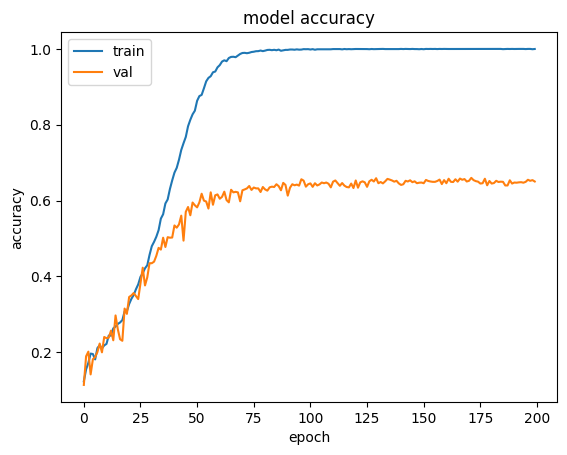

2024-12-17 00:43:08,494 - INFO - Export plot results: ./experiments/ModelCNNExp1-20241216_BRCBJJ9G5/logs/20241217-004308_aug_model_ModelCNNExp1_imagenet_frozen_False_ep200_bs_32_acc_tr1.0_va0.75_te0.65625_accuracy_plot.png


<Figure size 640x480 with 0 Axes>

In [22]:
metrics_string = f"acc_tr{train_score[1]}_va{valid_score[1]}_te{test_score[1]}"

current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_"
            f"{metrics_string}_"
            f"accuracy_plot.png")

plt.plot(training_exper_model_eff.history['accuracy'])
plt.plot(training_exper_model_eff.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
plt.savefig(fig_name)
logger.info(f"Export plot results: {fig_name}")

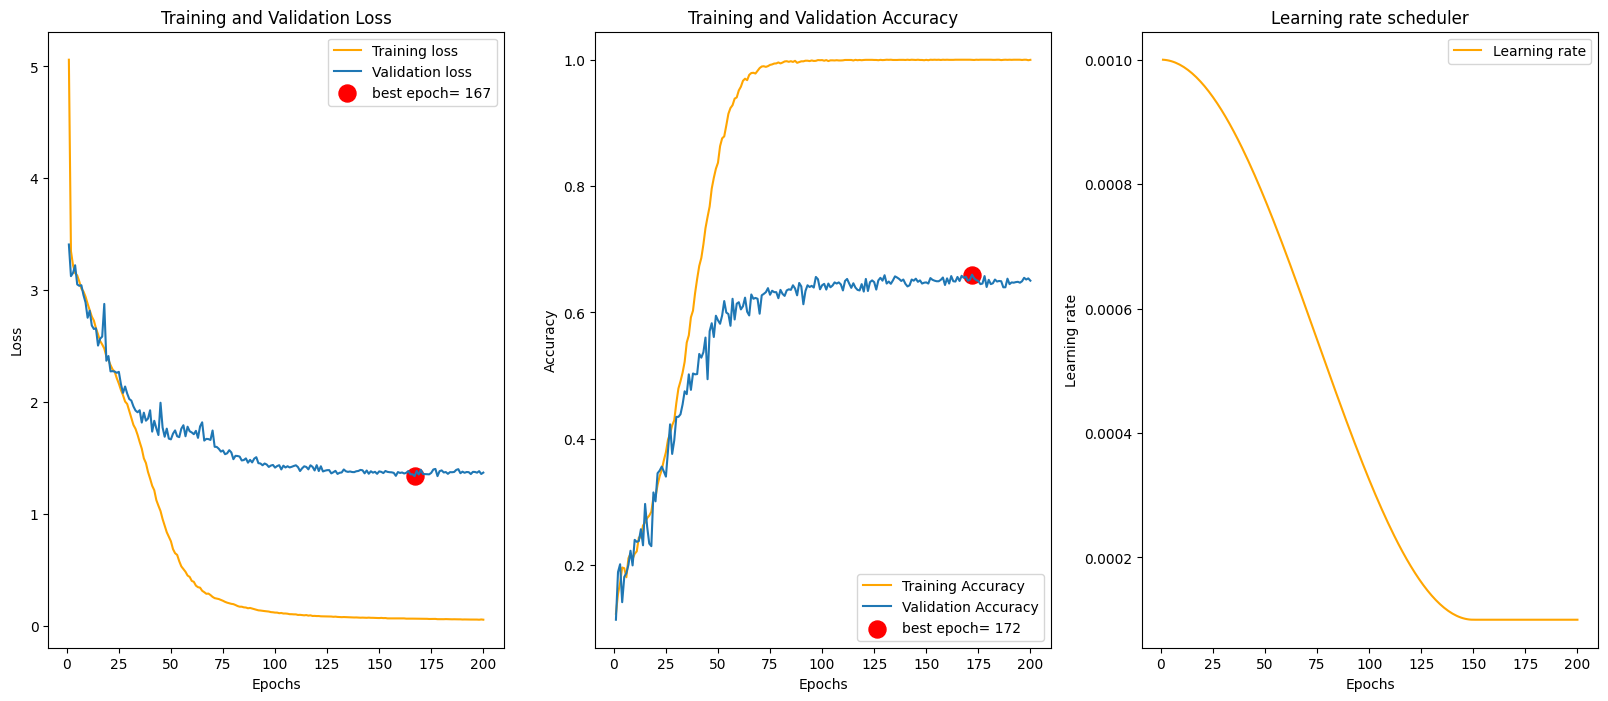

2024-12-17 00:43:08,812 - INFO - Export plot results: ./experiments/ModelCNNExp1-20241216_BRCBJJ9G5/logs/20241217-004308_aug_model_ModelCNNExp1_imagenet_frozen_False_ep200_bs_32_cosine_decay_scheduler_accuracy_loss_acc_tr1.0_va0.75_te0.65625_plots.png
2024-12-17 00:43:08,812 - INFO - Train loss: 0.050413839519023895
Train Accuracy: 1.0
Validation loss: 1.0319783687591553
Validation Accuracy: 0.75
Test Loss: 1.5887997150421143
Test Accuracy: 0.65625


<Figure size 640x480 with 0 Axes>

In [23]:
# Plot
fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_"
            f"{metrics_string}"
            f"_plots.png")
# Define needed variables
tr_acc = training_exper_model_eff.history['accuracy']
tr_loss = training_exper_model_eff.history['loss']
val_acc = training_exper_model_eff.history['val_accuracy']
val_loss = training_exper_model_eff.history['val_loss']

learning_rate_logs = training_exper_model_eff.history['learning_rate']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
# index_lr = np.argmin(learning_rate)

loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

Epochs = [i + 1 for i in range(len(tr_acc))]

# Plot training history
plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.plot(Epochs, tr_loss, 'orange', label='Training loss')
plt.plot(Epochs, val_loss, label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='red', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(Epochs, tr_acc, 'orange', label='Training Accuracy')
plt.plot(Epochs, val_acc, label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='red', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(Epochs, learning_rate_logs, 'orange', label='Learning rate')
plt.title('Learning rate scheduler')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.legend()
plt.show()
plt.savefig(fig_name)
logger.info(f"Export plot results: {fig_name}")

try:
    logger.info(f"Train loss: {train_score[0]}"
                f"\nTrain Accuracy: {train_score[1]}"
                f"\nValidation loss: {valid_score[0]}"
                f"\nValidation Accuracy: {valid_score[1]}"
                f"\nTest Loss: {test_score[0]}"
                f"\nTest Accuracy: {test_score[1]}")
except Exception as e:
    print(f"Unable to log evaluation score"
          f"\n Reason: {e}")






In [24]:
# Compute confusion matrix and plot figure

/tmp/ipykernel_408753/2623250881.py:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  preds = model_new.predict_generator(test_data)
2024-12-17 00:43:12,232 - INFO -                    precision    recall  f1-score   support

american_football       0.73      0.59      0.66        96
         baseball       0.62      0.68      0.65       100
       basketball       0.72      0.65      0.68        86
    billiard_ball       0.78      0.76      0.77       162
     bowling_ball       0.48      0.49      0.48       111
     cricket_ball       0.73      0.75      0.74       146
         football       0.69      0.61      0.65       151
        golf_ball       0.49      0.59      0.54       138
      hockey_ball       0.63      0.56      0.60       133
      hockey_puck       0.57      0.61      0.59        98
       rugby_ball       0.69      0.64      0.66       124
      shuttlecock    

[ 9  7  4 ... 14  8  5]
Confusion Matrix, Without Normalization
[[ 57   4   3   1   0   4   2   2   2   5   8   0   4   4   0]
 [  3  68   0   1   4   1   2   5   1   5   2   2   2   3   1]
 [  5   1  56   0   5   1   2   2   3   4   1   0   1   0   5]
 [  0   4   0 123   6   1   4   8   0   1   1   1  10   1   2]
 [  1   3   3   6  54   8   2   5   3   6   2   2   7   4   5]
 [  1   0   3   1   2 109   1   5   6   3   1   1   5   8   0]
 [  1   3   1   1   8   3  92   9   7   3   8   1   5   1   8]
 [  1   1   2   3   3   4   2  81   8   5   5   4  13   6   0]
 [  1   4   2   4   3   4   6  11  75   2   0   1  11   7   2]
 [  1   1   2   2   5   6   2   5   2  60   0   5   4   0   3]
 [  6   5   2   0   6   0   8   2   0   5  79   4   3   3   1]
 [  0   4   1   3   2   4   1   7   0   2   4  62   9   5   4]
 [  1   6   1  10   5   1   1  10   4   0   3   5 104   5   0]
 [  0   1   0   0   2   1   3   6   4   2   1   6   5  92   0]
 [  0   4   2   2   7   2   6   6   4   2   0   1   3 

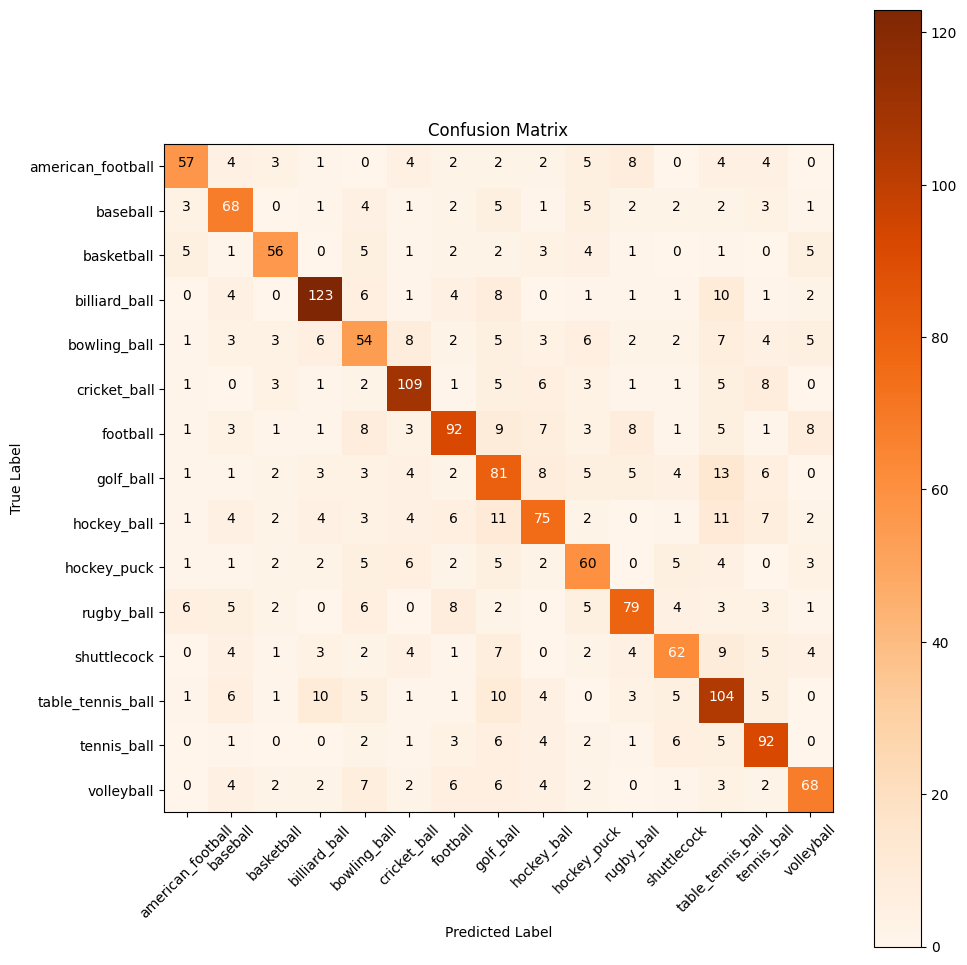

In [25]:
preds = model_new.predict_generator(test_data)
y_pred = np.argmax(preds, axis=1)
print(y_pred)
target_names = ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball', 'cricket_ball',
                'football', 'golf_ball', 'hockey_ball', 'hockey_puck', 'rugby_ball', 'shuttlecock',
                'table_tennis_ball', 'tennis_ball', 'volleyball']
# Classification report
logger.info(classification_report(test_data.classes, y_pred, target_names=target_names))

fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_"
            f"{metrics_string}"
            f"_confusion_mat.png")
# Confusion matrix
cm = confusion_matrix(test_data.classes, y_pred)
plot_confusion_matrix(cm=cm, classes=target_names, title='Confusion Matrix', figname=fig_name)




In [26]:
# Save everything
acc = test_score[1] * 100
save_path = checkpoints_dir

# Save history
history_filename = f"{logs_text_dir}/{model_sel}-{current_timestamp}.npy"
np.save(history_filename, training_exper_model_eff.history)

logger.info(f'model training history was saved as {history_filename}')

# Save model
save_id = str(f'{exp_save_name}-{"%.2f" % round(acc, 2)}.h5')
model_save_loc = os.path.join(save_path, save_id)
model_new.save(model_save_loc)
logger.info(f'model was saved as {model_save_loc}')

# Save weights
weight_save_id = str(f'{exp_save_name}-{"%.2f" % round(acc, 2)}-weights.h5')
weights_save_loc = os.path.join(save_path, weight_save_id)
model_new.save_weights(weights_save_loc)
logger.info(f'weights were saved as {weights_save_loc}')

elapsed_time = time.time() - start_time
logger.info(f"{current_timestamp}: Processing time: {elapsed_time} seconds. Saved plot to {fig_name} \n")
logger.info(time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))
logger.info(f"Finished!")


2024-12-17 00:43:12,928 - INFO - model training history was saved as ./experiments/ModelCNNExp1-20241216_BRCBJJ9G5/logs/ModelCNNExp1-20241217-004308.npy
/home/phuocddat/git-repo/msc_ai/chest_xray/env_chest_xray/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2024-12-17 00:43:13,207 - INFO - model was saved as ./experiments/ModelCNNExp1-20241216_BRCBJJ9G5/checkpoints/20241216-235938___model_ModelCNNExp1_config_5_imagenet_frozen_Adamax_bs_16_frozen_False_cosine__aug-65.62.h5
2024-12-17 00:43:13,304 - INFO - weights were saved as ./experiments/ModelCNNExp1-20241216_BRCBJJ9G5/checkpoints/20241216-235938___model_ModelCNNExp1_config_5_imagenet_frozen_Adamax_bs_16_frozen_False_cosine__aug-65.62-weights.h5
2024-12-17 00:43:13,304 - INFO - 20241217-004308